<a href="https://colab.research.google.com/github/nycujack/Machine_Learning_Projects2/blob/main/%E5%93%A1%E5%B7%A5%E9%9B%A2%E8%81%B7%E9%A0%90%E6%B8%AC%E5%B0%88%E6%A1%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#pip install sklearn
import pandas as pd
import numpy as np

# 繪圖相關套件
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
import seaborn as sns
plt.style.use( 'ggplot' )

# 標籤編碼(Label)、獨熱編碼(OneHot)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# 決策樹(Decision Tree)
from sklearn.tree import DecisionTreeClassifier
# 隨機森林(Random Forest)
from sklearn.ensemble import RandomForestClassifier

from IPython.display import display
import warnings
warnings.filterwarnings( 'ignore' )

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving season.csv to season (1).csv
Saving submission.csv to submission (1).csv
Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [ ]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
submit = pd.read_csv('submission.csv')

print( f'train {df_train.shape}' )
display( df_train.head() )

print( f'\ntest {df_test.shape}' )
display( df_test.head() )

train (14392, 47)


,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,工作資歷1,工作資歷2,...,年資層級A,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門
0,2014,1,0,1.0,1.0,3.0,19.0,4.0,0.0,1.0,...,2.0,1.0,1.0,2.0,NaN,NaN,5.0,0.0,8.0,19138.0
1,2015,1,0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,...,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
2,2016,1,0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,...,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
3,2017,1,0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,...,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
4,2014,3,0,0.0,1.0,4.0,8.0,1.0,0.0,0.0,...,5.0,5.0,0.0,0.0,2.0,4.0,1.0,2.0,8.0,8181.0



test (3739, 47)


,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,工作資歷1,工作資歷2,...,年資層級A,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門
0,2018,1,NaN,1.0,1.0,3.0,19.0,6.0,0.0,1.0,...,3.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
1,2018,3,NaN,0.0,1.0,4.0,8.0,1.0,0.0,0.0,...,6.0,6.0,0.0,0.0,2.0,4.0,1.0,2.0,8.0,8181.0
2,2018,7,NaN,0.0,1.0,4.0,4.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,NaN,NaN,5.0,0.0,10.0,4010.0
3,2018,15,NaN,0.0,1.0,4.0,2.0,4.0,0.0,0.0,...,3.0,1.0,4.0,2.0,NaN,4.0,8.0,2.0,9.0,2177.0
4,2018,16,NaN,0.0,1.0,4.0,12.0,1.0,0.0,0.0,...,3.0,1.0,3.0,1.0,2.0,3.0,3.0,2.0,10.0,12072.0


# 欄位型態

In [ ]:
# 定義判別欄位型態的函數
def Col_Types( Data ):
    Column_Types = Data.dtypes.to_frame().reset_index()   # 判別每個欄位的型態
    Column_Types.columns = ['ColumnName','Type']
    Column_Types.sort_values( by='Type', inplace=True )
    return Column_Types

In [ ]:
display( Col_Types(df_train) )

,ColumnName,Type
0,yyyy,int64
1,PerNo,int64
2,PerStatus,int64
26,近一年請假數A,float64
27,近三月請假數B,float64
28,近一年請假數B,float64
29,出差數A,float64
30,出差數B,float64
31,出差集中度,float64
32,年度績效等級A,float64


# **遺漏值**

In [ ]:
# 定義用來統計欄位缺漏值總數的函數
def Missing_Counts( Data ) :
    missing = Data.isnull().sum()  # 計算欄位中缺漏值的數量
    missing = missing[ missing>0 ]
    missing.sort_values( inplace=True )

    Missing_Count = pd.DataFrame( { 'ColumnName':missing.index, 'MissingCount':missing.values } )  # Convert Series to DataFrame
    Missing_Count[ 'Percentage(%)' ] = Missing_Count['MissingCount'].apply( lambda x:round(x/Data.shape[0]*100,2) )
    return  Missing_Count

In [ ]:
print( 'train :' )
display( Missing_Counts(df_train) )

print( 'test :' )
display( Missing_Counts(df_test) )

train :


,ColumnName,MissingCount,Percentage(%)
0,sex,73,0.51
1,近一年請假數A,73,0.51
2,近三月請假數B,73,0.51
3,近一年請假數B,73,0.51
4,出差數A,73,0.51
5,出差數B,73,0.51
6,出差集中度,73,0.51
7,年度績效等級A,73,0.51
8,年度績效等級B,73,0.51
9,年度績效等級C,73,0.51


test :


,ColumnName,MissingCount,Percentage(%)
0,升遷速度,18,0.48
1,近三月請假數A,18,0.48
2,近一年請假數A,18,0.48
3,近三月請假數B,18,0.48
4,近一年請假數B,18,0.48
5,出差數A,18,0.48
6,出差數B,18,0.48
7,出差集中度,18,0.48
8,年度績效等級A,18,0.48
9,通勤成本,18,0.48


## 統計量(Statistic)
利用 describe( ) 函數，我們可得到每個數值型態欄位的統計量，其用意是為往後我們在觀察欄位是否存有離群值(Outlier)時，作為一個判斷的參考依據，另外，也可用來觀察每個欄位的尺度(scale)是否相似，在餵資料進入模型訓練之前，決定是否需進行資料的正規化(Normalization)或標準化(Standardization)。

In [ ]:
#pd.set_option('display.max_columns', None)  # 顯示所有欄位
#pd.set_option('display.max_rows', None)     # 顯示所有列

print( 'train' )
display( df_train.describe(include='all') )  # 使用 include='all' 顯示所有欄位類型

print( 'test' )
display( df_test.describe(include='all') )  # 使用 include='all' 顯示所有欄位類型

train


,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,工作資歷1,工作資歷2,...,年資層級A,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門
count,14392.000000,14392.000000,14392.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,...,14319.000000,14319.000000,14319.000000,14319.000000,9066.000000,10551.000000,14319.000000,14319.000000,14319.000000,14319.000000
mean,2015.520220,4410.755489,0.055309,0.701306,1.109365,4.375655,12.833927,1.791885,0.029122,0.051749,...,3.619806,3.100286,1.151477,0.737831,2.054048,3.491044,5.686221,1.072561,8.333124,12932.624206
std,1.116459,2530.042411,0.228589,0.457701,0.312108,1.736769,5.634432,1.543562,0.168155,0.221528,...,1.769711,1.774830,1.454685,0.762465,0.312546,0.866923,2.417362,0.923064,1.247291,5625.608973
min,2014.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2029.000000
25%,2015.000000,2237.000000,0.000000,0.000000,1.000000,3.000000,8.000000,1.000000,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,2.000000,3.000000,3.000000,0.000000,8.000000,8145.000000
50%,2016.000000,4387.000000,0.000000,1.000000,1.000000,4.000000,14.000000,1.000000,0.000000,0.000000,...,3.000000,3.000000,1.000000,1.000000,2.000000,4.000000,6.000000,1.000000,8.000000,14040.000000
75%,2017.000000,6613.250000,0.000000,1.000000,1.000000,7.000000,18.000000,1.000000,0.000000,0.000000,...,5.000000,4.000000,2.000000,1.000000,2.000000,4.000000,8.000000,2.000000,8.000000,18111.000000
max,2017.000000,8775.000000,1.000000,1.000000,2.000000,8.000000,20.000000,6.000000,1.000000,1.000000,...,9.000000,8.000000,9.000000,7.000000,3.000000,5.000000,9.000000,3.000000,16.000000,20208.000000


test


,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,工作資歷1,工作資歷2,...,年資層級A,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門
count,3739.0,3739.000000,0.0,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,...,3721.000000,3721.000000,3721.000000,3721.000000,2355.000000,2672.000000,3721.000000,3721.000000,3721.000000,3721.000000
mean,2018.0,4424.536507,NaN,0.683687,1.119323,4.306369,13.001075,1.882827,0.030099,0.049449,...,3.682612,3.088417,1.310669,0.798173,2.040764,3.504865,5.680193,1.084117,8.324913,13100.148347
std,0.0,2509.719694,NaN,0.465099,0.324211,1.721210,5.691013,1.602662,0.170884,0.216833,...,1.699475,1.746726,1.584779,0.796063,0.267217,0.857922,2.415198,0.924382,1.238298,5683.356074
min,2018.0,1.000000,NaN,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2029.000000
25%,2018.0,2287.000000,NaN,0.000000,1.000000,3.000000,8.000000,1.000000,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,2.000000,3.000000,3.000000,0.000000,8.000000,8157.000000
50%,2018.0,4412.000000,NaN,1.000000,1.000000,4.000000,14.000000,1.000000,0.000000,0.000000,...,3.000000,3.000000,1.000000,1.000000,2.000000,4.000000,6.000000,1.000000,8.000000,14040.000000
75%,2018.0,6541.500000,NaN,1.000000,1.000000,7.000000,19.000000,2.000000,0.000000,0.000000,...,5.000000,4.000000,2.000000,1.000000,2.000000,4.000000,8.000000,2.000000,8.000000,19039.000000
max,2018.0,8775.000000,NaN,1.000000,2.000000,8.000000,20.000000,6.000000,1.000000,1.000000,...,9.000000,9.000000,9.000000,7.000000,3.000000,6.000000,9.000000,3.000000,16.000000,20208.000000


檢視問卷填答人分布


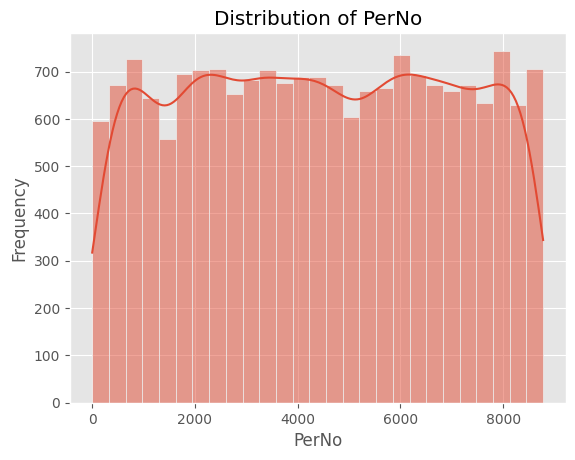

In [ ]:
sns.histplot(data=df_data, x='PerNo', kde=True)  # Remove extra spaces/tab characters
plt.title('Distribution of PerNo')
plt.xlabel('PerNo')
plt.ylabel('Frequency')
plt.show()

In [ ]:
frequency_table = pd.DataFrame(df_data['PerNo'].value_counts())
frequency_table.index.name = 'PerNo'
frequency_table.columns = ['Frequency']

# Print the frequency table
print(frequency_table)

       Frequency
PerNo           
1              5
4950           5
4919           5
4920           5
4924           5
...          ...
1055           1
6830           1
6832           1
1031           1
8735           1

[4965 rows x 1 columns]


檢視每年問券數量

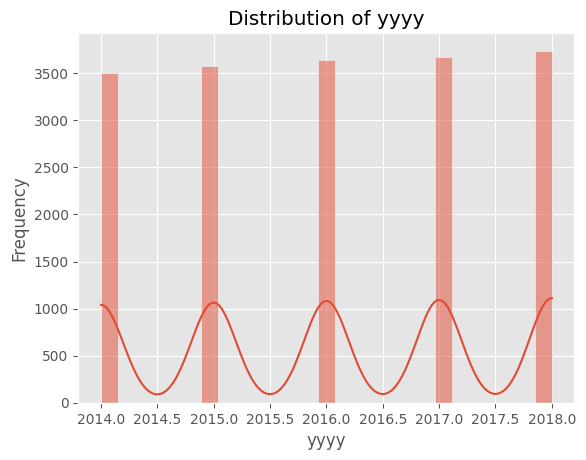

In [ ]:
sns.histplot(data=df_data, x='yyyy', kde=True)  # Remove extra spaces/tab characters
plt.title('Distribution of yyyy')
plt.xlabel('yyyy')
plt.ylabel('Frequency')
plt.show()

每人填答次數不均但整體相差沒有太大加上每年總資料相近因此為簡化分析不做逐年處理

# 數據合併
在大致瞭解資料的基本態樣後，我們便可開始對資料做一些關聯性分析。由於是對整體資料進行分析，因此我們先使用 append( ) 函數將訓練集與測試集合併，方便後續一併修補或調整資料。
並將工作資歷1 工作資歷2 工作資歷3 工作資歷4 工作資歷5欄刪除並合併為工作資歷等級




In [ ]:
# 合併train及test的資料
df_data = pd.concat([df_train, df_test], ignore_index=True)
#df_data=df_data[df_data.yyyy==2014]
df_data.head()

,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,工作資歷1,工作資歷2,...,年資層級A,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門
0,2014,1,0.0,1.0,1.0,3.0,19.0,4.0,0.0,1.0,...,2.0,1.0,1.0,2.0,NaN,NaN,5.0,0.0,8.0,19138.0
1,2015,1,0.0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,...,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
2,2016,1,0.0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,...,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
3,2017,1,0.0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,...,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
4,2014,3,0.0,0.0,1.0,4.0,8.0,1.0,0.0,0.0,...,5.0,5.0,0.0,0.0,2.0,4.0,1.0,2.0,8.0,8181.0


將各個工作資歷合併為工作資歷等級以簡化變數

In [ ]:
# 假設您的數據框名為 df_data
df_data['工作資歷等級'] = 0  # 初始化新變數

# 使用迴圈和條件判斷賦值
for i in range(1, 6):
    col_name = f'工作資歷{i}'  # 動態生成欄位名稱
    df_data.loc[df_data[col_name] == 1, '工作資歷等級'] = i
columns_to_drop = ['工作資歷1', '工作資歷2', '工作資歷3', '工作資歷4', '工作資歷5']
df_data = df_data.drop(columns=columns_to_drop)
df_data.head()

,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,專案時數,專案總數,...,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門,工作資歷等級
0,2014,1,0.0,1.0,1.0,3.0,19.0,4.0,23.0,1.0,...,1.0,1.0,2.0,NaN,NaN,5.0,0.0,8.0,19138.0,3
1,2015,1,0.0,1.0,1.0,3.0,19.0,6.0,23.0,2.0,...,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0,3
2,2016,1,0.0,1.0,1.0,3.0,19.0,6.0,23.0,3.0,...,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0,3
3,2017,1,0.0,1.0,1.0,3.0,19.0,6.0,23.0,4.0,...,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0,3
4,2014,3,0.0,0.0,1.0,4.0,8.0,1.0,23.0,4.0,...,5.0,0.0,0.0,2.0,4.0,1.0,2.0,8.0,8181.0,0


# 分析離職比率
首先，我們分析在職者與離職者的比例是否有明顯極大的落差。


In [ ]:
PerStatus_Counts = df_data['PerStatus'].value_counts().reset_index()
PerStatus_Counts.columns = ['PerStatus','Counts']
PerStatus_Counts

,PerStatus,Counts
0,0.0,13596
1,1.0,796


在職者與離職者的比例有明顯極大的落差，因此模型上使用隨機森林模型以減少資料不均的影響

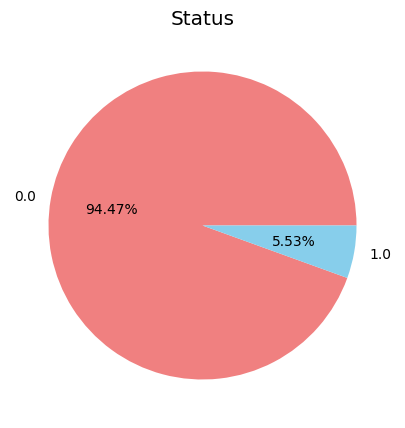

In [ ]:
plt.figure( figsize=(10,5) )
df_data['PerStatus'].value_counts().plot( kind='pie', colors=['lightcoral','skyblue'], autopct='%1.2f%%' )
plt.title( 'Status' )  # 圖標題
plt.ylabel( '' )
plt.show()

# 質化變數
列出資料中的質化變數（Qualitative Variables）並進行 frequency 檢查 是指統計這些變數中每個類別的出現次數，以了解資料的分布情況。

In [ ]:
for col in ['sex', '婚姻狀況', '工作分類', '最高學歷', '歸屬部門', '工作地點' ,'畢業科系類別','畢業學校類別','管理層級','廠區代碼']:
    print(f'{col}:')
    print(df_data[col].value_counts())
    print('\n')

sex:
sex
1.0    12586
0.0     5454
Name: count, dtype: int64


婚姻狀況:
婚姻狀況
1.0    13260
2.0     4759
3.0       21
Name: count, dtype: int64


工作分類:
工作分類
1.0    16030
2.0     2010
Name: count, dtype: int64


最高學歷:
最高學歷
2.0    10337
3.0      835
1.0      249
Name: count, dtype: int64


歸屬部門:
歸屬部門
14040.0    429
20019.0    427
8157.0     427
20208.0    412
14067.0    387
          ... 
10088.0      5
14207.0      4
20062.0      4
14179.0      2
19076.0      1
Name: count, Length: 139, dtype: int64


工作地點:
工作地點
6.0     13579
5.0      2539
11.0      602
3.0       475
2.0       303
1.0       258
4.0       149
8.0        84
13.0       39
9.0        10
10.0        2
Name: count, dtype: int64


畢業科系類別:
畢業科系類別
8.0    3918
3.0    3420
6.0    2957
5.0    2316
9.0    2142
7.0    1255
2.0    1095
1.0     790
4.0     147
Name: count, dtype: int64


畢業學校類別:
畢業學校類別
4.0    7543
3.0    4287
1.0     950
5.0     442
6.0       1
Name: count, dtype: int64


管理層級:
管理層級
1.0    13739
4.0     2270
6.0     1188
2.

由婚姻狀態和年齡的比對我們可以推測1為已婚，2為未婚,3為其他

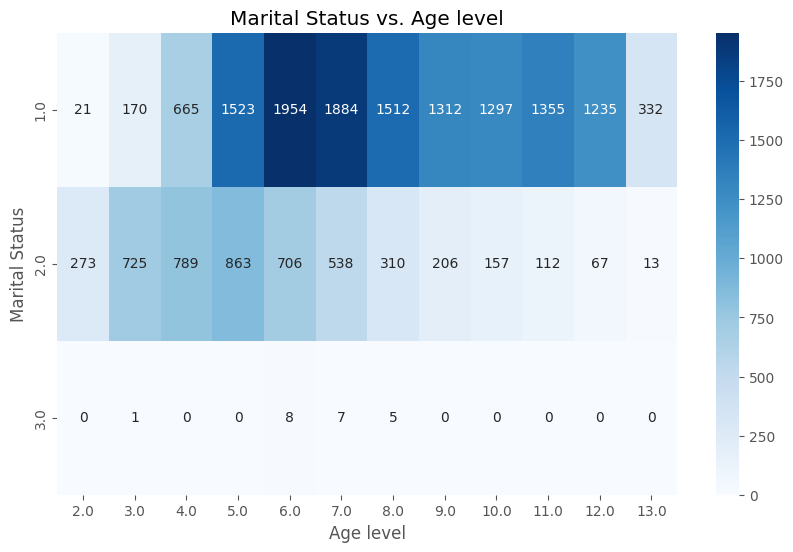

In [ ]:
cross_tab = pd.crosstab(df_data['婚姻狀況'], df_data['年齡層級'])

# Plot the cross-tabulation as a heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="Blues")  # fmt="d" to display numbers as integers
plt.title("Marital Status vs. Age level")  # Add title
plt.xlabel("Age level")  # Label x-axis
plt.ylabel("Marital Status")  # Label y-axis
plt.show()

# 相關係數(Correlation)
利用 corr( ) 函數，計算特徵欄位彼此間的相關係數，可作為後續決定篩選哪些特徵欄位，來餵入模型進行訓練。觀察PerStatus欄位與其他特徵欄位的相關係數，發覺彼此間並無明顯的線性關係。

In [ ]:
# Survied 與其他欄位間的相關係數
Corr_Matrix = df_train.select_dtypes(include=np.number).corr()  # 計算相關係數, 只選取數值型態欄位
Corr = Corr_Matrix.loc['PerStatus',:].sort_values()[:-1]
Corr = pd.DataFrame({ 'PerStatus':Corr })
Corr

,PerStatus
年資層級A,-0.123799
年齡層級,-0.121276
年資層級B,-0.119661
升遷速度,-0.074782
眷屬量,-0.074278
工作分類,-0.046693
特殊專案佔比,-0.042096
任職前工作平均年數,-0.042090
年度績效等級C,-0.037324
出差數A,-0.036722


## 離職率
我們分別觀察(歸屬部門 生產總額 年齡層級 近一年請假數A 近三月請假數A 年度績效等級B 訓練時數C 畢業科系類別 廠區代碼 年資層級A)與離職率(PerStatus)的關係。

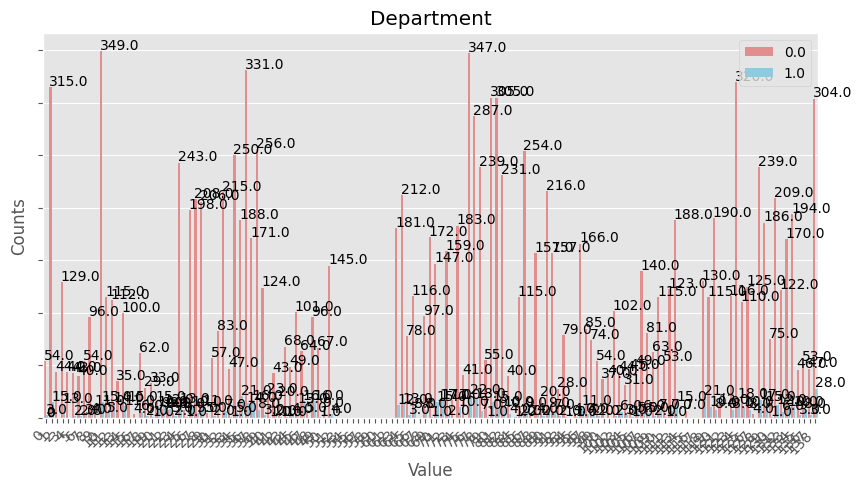

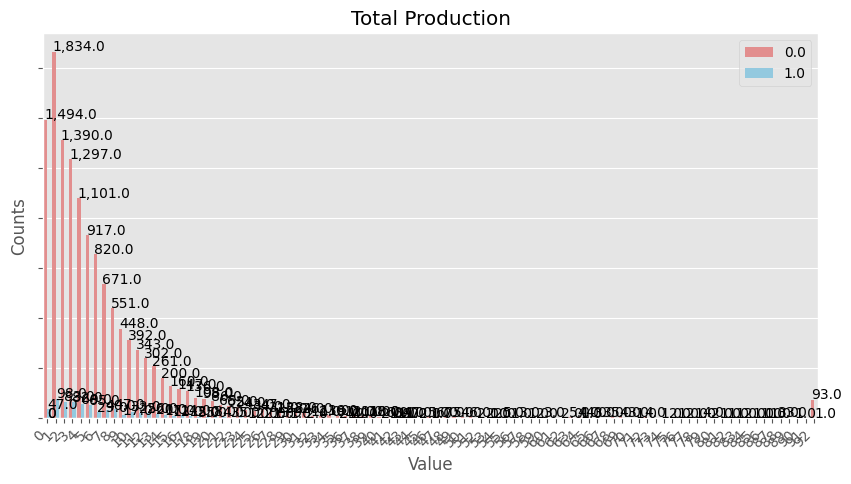

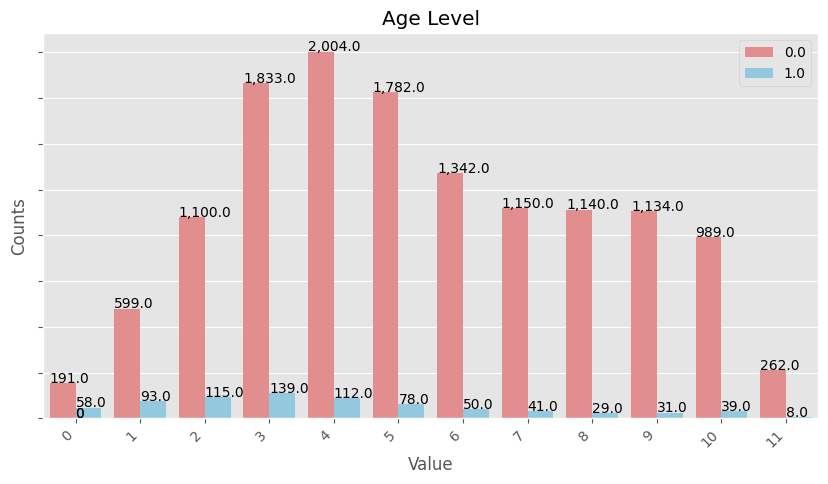

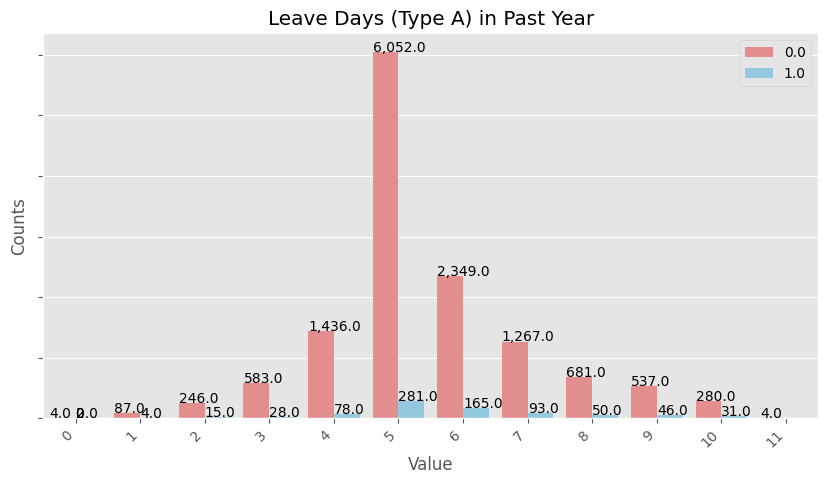

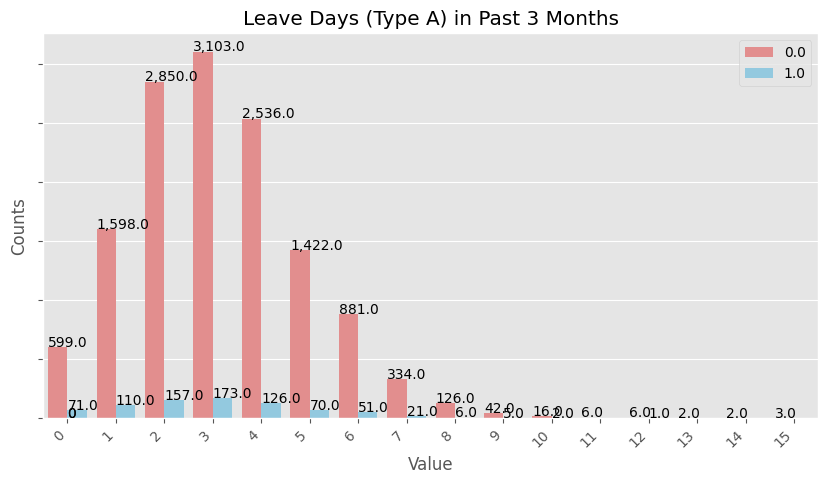

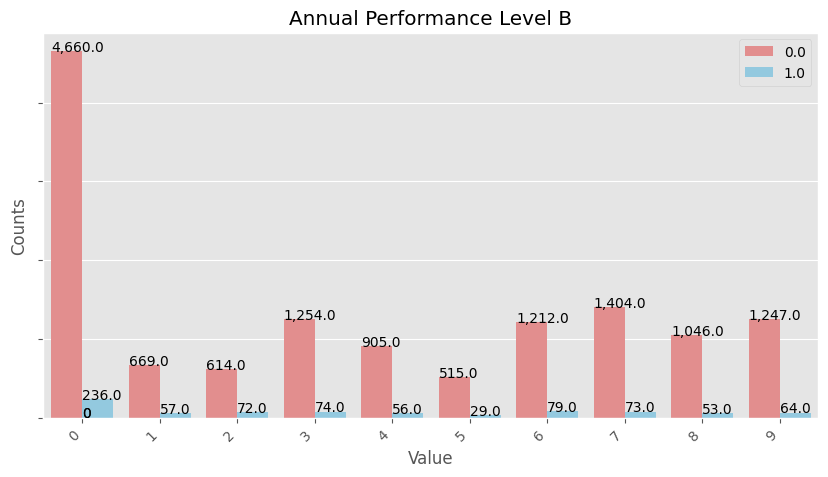

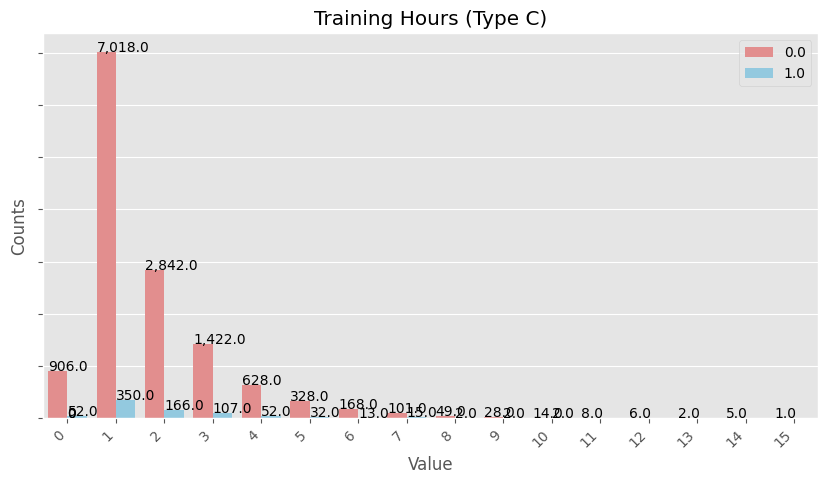

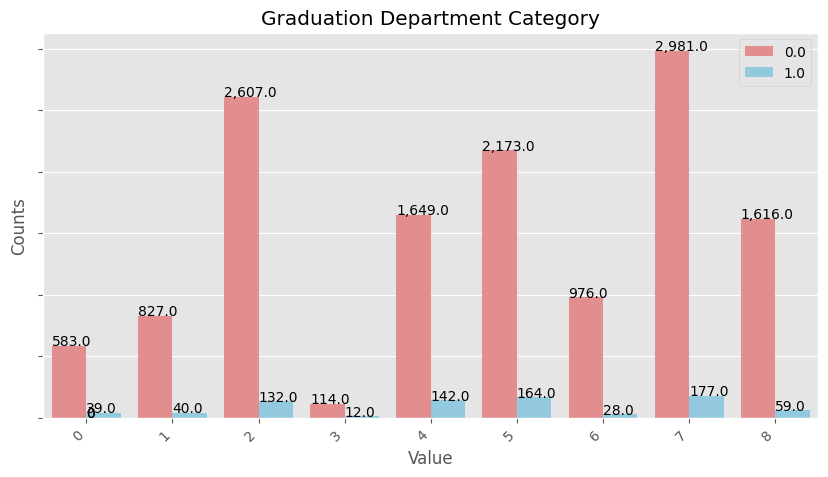

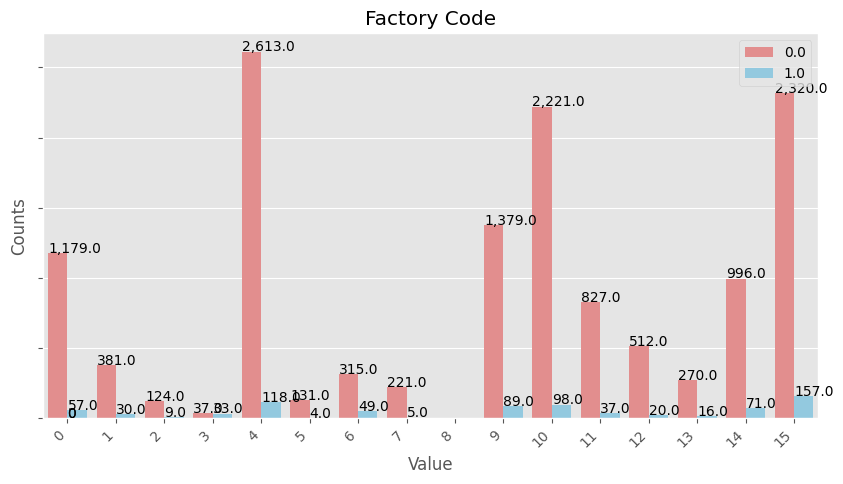

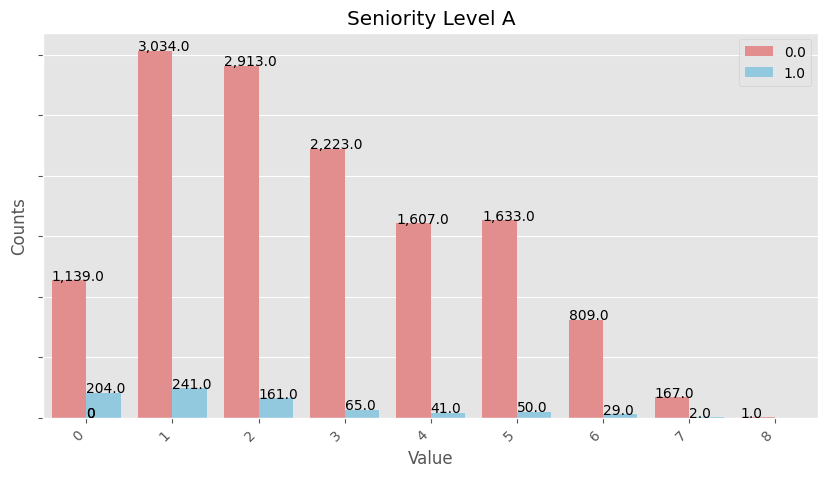

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

variables = ['歸屬部門', '生產總額', '年齡層級', '近一年請假數A', '近三月請假數A', '年度績效等級B', '訓練時數C', '畢業科系類別', '廠區代碼', '年資層級A']

# English titles for each variable
english_titles = {
    'yyyy': 'Year',
    'PerNo': 'Employee ID',
    'PerStatus': 'Turnover Status',
    '近一年請假數A': 'Leave Days (Type A) in Past Year',
    '近三月請假數B': 'Leave Days (Type B) in Past 3 Months',
    '近一年請假數B': 'Leave Days (Type B) in Past Year',
    '出差數A': 'Business Trip Count (Type A)',
    '出差數B': 'Business Trip Count (Type B)',
    '出差集中度': 'Business Trip Concentration',
    '年度績效等級A': 'Annual Performance Level A',
    '年度績效等級B': 'Annual Performance Level B',
    '年度績效等級C': 'Annual Performance Level C',
    '婚姻狀況': 'Marital Status',
    '近三月請假數A': 'Leave Days (Type A) in Past 3 Months',
    '年資層級A': 'Seniority Level A',
    '年資層級B': 'Seniority Level B',
    '年資層級C': 'Seniority Level C',
    '任職前工作平均年數': 'Average Years of Previous Work Experience',
    '最高學歷': 'Highest Education',
    '畢業學校類別': 'Graduation School Category',
    '畢業科系類別': 'Graduation Department Category',
    '眷屬量': 'Number of Dependents',
    '年齡層級': 'Age Level',
    '升遷速度': 'Promotion Speed',
    '是否升遷': 'Promotion Status',
    '榮譽數': 'Number of Honors',
    'sex': 'Gender',
    '工作分類': 'Job Category',
    '職等': 'Job Level',
    '廠區代碼': 'Factory Code',
    '管理層級': 'Management Level',
    '工作資歷1': 'Work Experience 1',
    '工作資歷2': 'Work Experience 2',
    '工作資歷3': 'Work Experience 3',
    '工作資歷4': 'Work Experience 4',
    '工作資歷5': 'Work Experience 5',
    '專案時數': 'Project Hours',
    '專案總數': 'Total Projects',
    '當前專案角色': 'Current Project Role',
    '特殊專案佔比': 'Special Project Ratio',
    '工作地點': 'Work Location',
    '訓練時數A': 'Training Hours (Type A)',
    '訓練時數B': 'Training Hours (Type B)',
    '訓練時數C': 'Training Hours (Type C)',
    '生產總額': 'Total Production',
    '通勤成本': 'Commuting Cost',
    '歸屬部門': 'Department'
}

# Loop through each variable
for var in variables:
    melted_data = pd.melt(df_data, id_vars=['PerStatus'], value_vars=[var], var_name='Category', value_name='Value')

    # Convert 'Value' column to integers if possible
    try:
        melted_data['Value'] = melted_data['Value'].astype(int)
    except ValueError:
        pass # If conversion fails, keep the original data type

    # Create a new figure for each plot
    plt.figure(figsize=(10, 5))

    # Now use the melted data with countplot and set English title
    ax = sns.countplot(x='Value', hue='PerStatus', data=melted_data, palette=['lightcoral', 'skyblue'])
    ax.set_title(english_titles.get(var, var))  # Use English title if available, otherwise use original variable name

    ax.set_yticklabels([])
    ax.set_ylabel('Counts')
    ax.legend(loc=1)

    # Format x-axis labels as integers
    ax.set_xticklabels(ax.get_xticks(), rotation=45, ha='right')  # Rotate for better visibility
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))


    for p in ax.patches:
        ax.annotate('{:,}'.format(p.get_height()), (p.get_x(), p.get_height() + 1.5))

    plt.show() # Display the plot for the current variable

In [ ]:
for var in variables:
    l = ['PerStatus', var]
    # Group by the current variable 'var'
    Turnover_Rate = df_data[l].groupby(by=var).mean().round(4).reset_index()
    Turnover_Rate.columns = [var, 'turnover Rate(%)']
    # Assuming Survival_Rate is a DataFrame with 'turnover Rate(%)' column
    Turnover_Rate['turnover Rate(%)'] = Turnover_Rate['turnover Rate(%)'].map(lambda x: x * 100)
    display(Turnover_Rate)

,歸屬部門,turnover Rate(%)
0,2029.0,5.26
1,2058.0,4.55
2,2098.0,0.00
3,2101.0,9.15
4,2128.0,0.00
...,...,...
134,20130.0,4.90
135,20134.0,6.12
136,20184.0,13.11
137,20192.0,6.00


,生產總額,turnover Rate(%)
0,0.0,3.05
1,1.0,5.07
2,2.0,5.63
3,3.0,5.95
4,4.0,5.90
...,...,...
88,96.0,0.00
89,97.0,0.00
90,98.0,0.00
91,99.0,NaN


,年齡層級,turnover Rate(%)
0,2.0,23.29
1,3.0,13.44
2,4.0,9.47
3,5.0,7.05
4,6.0,5.29
5,7.0,4.19
6,8.0,3.59
7,9.0,3.44
8,10.0,2.48
9,11.0,2.66


,近一年請假數A,turnover Rate(%)
0,1.0,33.33
1,2.0,4.40
2,3.0,5.75
3,4.0,4.58
4,5.0,5.15
5,6.0,4.44
6,7.0,6.56
7,8.0,6.84
8,9.0,6.84
9,10.0,7.89


,近三月請假數A,turnover Rate(%)
0,0.0,10.60
1,1.0,6.44
2,2.0,5.22
3,3.0,5.28
4,4.0,4.73
5,5.0,4.69
6,6.0,5.47
7,7.0,5.92
8,8.0,4.55
9,9.0,10.64


,年度績效等級B,turnover Rate(%)
0,1.0,4.82
1,2.0,7.85
2,3.0,10.50
3,4.0,5.57
4,5.0,5.83
5,6.0,5.33
6,7.0,6.12
7,8.0,4.94
8,9.0,4.82
9,10.0,4.88


,訓練時數C,turnover Rate(%)
0,0.0,5.43
1,1.0,4.75
2,2.0,5.52
3,3.0,7.00
4,4.0,7.65
5,5.0,8.89
6,6.0,7.18
7,7.0,12.93
8,8.0,3.92
9,9.0,6.67


,畢業科系類別,turnover Rate(%)
0,1.0,6.27
1,2.0,4.61
2,3.0,4.82
3,4.0,9.52
4,5.0,7.93
5,6.0,7.02
6,7.0,2.79
7,8.0,5.60
8,9.0,3.52


,廠區代碼,turnover Rate(%)
0,2.0,4.61
1,4.0,7.30
2,5.0,6.77
3,6.0,47.14
4,8.0,4.32
5,9.0,2.96
6,10.0,13.46
7,11.0,2.21
8,12.0,NaN
9,13.0,6.06


,年資層級A,turnover Rate(%)
0,1.0,15.19
1,2.0,7.36
2,3.0,5.24
3,4.0,2.84
4,5.0,2.49
5,6.0,2.97
6,7.0,3.46
7,8.0,1.18
8,9.0,0.00


雖然廠區代碼3有較高的離職率，但因其資料大都缺失且廠區代碼為3的資料極少故難以用來辨識離職率


In [ ]:
factory_3_data = df_data[df_data['廠區代碼'] == 3]

# Calculate descriptive statistics
statistics = factory_3_data.describe(include='all')

# Display the statistics
print(statistics)

       yyyy  PerNo  PerStatus  sex  工作分類   職等  廠區代碼  管理層級  專案時數  專案總數  ...  \
count   0.0    0.0        0.0  0.0   0.0  0.0   0.0   0.0   0.0   0.0  ...   
mean    NaN    NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   
std     NaN    NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   
min     NaN    NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   
25%     NaN    NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   
50%     NaN    NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   
75%     NaN    NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   
max     NaN    NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   

       年資層級B  年資層級C  任職前工作平均年數  最高學歷  畢業學校類別  畢業科系類別  眷屬量  通勤成本  歸屬部門  工作資歷等級  
count    0.0    0.0        0.0   0.0     0.0     0.0  0.0   0.0   0.0     0.0  
mean     NaN    NaN        NaN   NaN     NaN     NaN  NaN   NaN   NaN     NaN  
std      NaN    NaN        NaN   NaN     NaN     NaN  NaN

In [ ]:
年度績效等級A_data = df_data[df_data['年度績效等級A'] == 8.0]

# Calculate descriptive statistics
statisticsB = 年度績效等級A_data.describe(include='all')

# Display the statistics
print(statisticsB)

         yyyy   PerNo  PerStatus  sex  工作分類   職等  廠區代碼  管理層級  專案時數  專案總數  ...  \
count     1.0     1.0        1.0  1.0   1.0  1.0   1.0   1.0   1.0   1.0  ...   
mean   2014.0  8276.0        1.0  1.0   1.0  7.0  20.0   1.0  11.0   1.0  ...   
std       NaN     NaN        NaN  NaN   NaN  NaN   NaN   NaN   NaN   NaN  ...   
min    2014.0  8276.0        1.0  1.0   1.0  7.0  20.0   1.0  11.0   1.0  ...   
25%    2014.0  8276.0        1.0  1.0   1.0  7.0  20.0   1.0  11.0   1.0  ...   
50%    2014.0  8276.0        1.0  1.0   1.0  7.0  20.0   1.0  11.0   1.0  ...   
75%    2014.0  8276.0        1.0  1.0   1.0  7.0  20.0   1.0  11.0   1.0  ...   
max    2014.0  8276.0        1.0  1.0   1.0  7.0  20.0   1.0  11.0   1.0  ...   

       年資層級B  年資層級C  任職前工作平均年數  最高學歷  畢業學校類別  畢業科系類別  眷屬量  通勤成本     歸屬部門  \
count    1.0    1.0        1.0   1.0     0.0     1.0  1.0   1.0      1.0   
mean     1.0    0.0        0.0   2.0     NaN     6.0  0.0   8.0  20192.0   
std      NaN    NaN        NaN   NaN     N

In [ ]:
年度績效等級C_data = df_data[df_data['年度績效等級C'] == 1.0]

# Calculate descriptive statistics
statisticsC = 年度績效等級C_data.describe(include='all')

# Display the statistics
print(statisticsC)

         yyyy        PerNo  PerStatus       sex      工作分類        職等  \
count     2.0     2.000000   2.000000  2.000000  2.000000  2.000000   
mean   2014.0  7142.500000   0.500000  0.500000  1.500000  5.000000   
std       0.0  1450.276008   0.707107  0.707107  0.707107  2.828427   
min    2014.0  6117.000000   0.000000  0.000000  1.000000  3.000000   
25%    2014.0  6629.750000   0.250000  0.250000  1.250000  4.000000   
50%    2014.0  7142.500000   0.500000  0.500000  1.500000  5.000000   
75%    2014.0  7655.250000   0.750000  0.750000  1.750000  6.000000   
max    2014.0  8168.000000   1.000000  1.000000  2.000000  7.000000   

            廠區代碼  管理層級       專案時數      專案總數  ...  年資層級B     年資層級C  任職前工作平均年數  \
count   2.000000   2.0   2.000000  2.000000  ...    2.0  2.000000   2.000000   
mean    8.000000   1.0  15.500000  1.500000  ...    6.0  0.500000   0.500000   
std     8.485281   0.0   7.778175  0.707107  ...    0.0  0.707107   0.707107   
min     2.000000   1.0  10.000000  1.000

In [ ]:
近一年請假數A_data = df_data[df_data['近一年請假數A'] == 1.0]

# Calculate descriptive statistics
statisticsD = 近一年請假數A_data.describe(include='all')

# Display the statistics
print(statisticsD)

              yyyy        PerNo  PerStatus  sex      工作分類        職等  \
count     6.000000     6.000000   6.000000  6.0  6.000000  6.000000   
mean   2015.333333  5400.833333   0.333333  1.0  1.166667  3.666667   
std       1.032796  3717.666979   0.516398  0.0  0.408248  0.516398   
min    2014.000000   528.000000   0.000000  1.0  1.000000  3.000000   
25%    2014.500000  2292.500000   0.000000  1.0  1.000000  3.250000   
50%    2016.000000  7286.000000   0.000000  1.0  1.000000  4.000000   
75%    2016.000000  8128.250000   0.750000  1.0  1.000000  4.000000   
max    2016.000000  8268.000000   1.000000  1.0  2.000000  4.000000   

            廠區代碼      管理層級       專案時數      專案總數  ...     年資層級B     年資層級C  \
count   6.000000  6.000000   6.000000  6.000000  ...  6.000000  6.000000   
mean   17.333333  1.500000  14.000000  1.333333  ...  3.333333  1.166667   
std     4.718757  1.224745  11.575837  0.516398  ...  1.751190  1.834848   
min     8.000000  1.000000   1.000000  1.000000  ...  2.

可以觀察到年度績效A和C及近一年請假次數A也皆屬於資料過少的情況因此不做額外處理

# scatter plot
因歸屬部門和生產總額種類太多難以觀察個別情況故繪製散布圖

In [ ]:
import seaborn as sns
#sns.pairplot(df_train)
#plt.show()

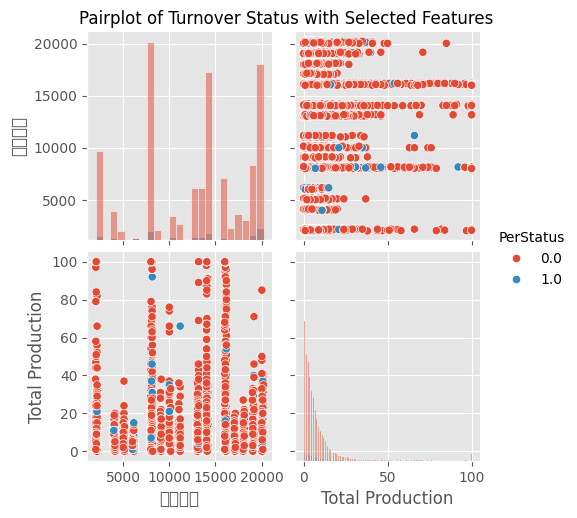

In [ ]:
selected_cols = ['PerStatus','歸屬部門', '生產總額']

df_selected = df_data[selected_cols]

# Convert categorical columns to numerical using Label Encoding if necessary
for col in df_selected.select_dtypes(include=['object']).columns:
    df_selected[col] = df_selected[col].astype('category').cat.codes

# Create the pairplot
g = sns.pairplot(df_selected, hue='PerStatus', diag_kind='hist')

# English titles for each variable
english_titles = {'職等': 'Job Level','廠區代碼': 'Factory Code','生產總額': 'Total Production'}

# Set English titles for x and y axes
for ax in g.axes.flat:
    ax.set_xlabel(english_titles.get(ax.get_xlabel(), ax.get_xlabel()))  # Use English title if available
    ax.set_ylabel(english_titles.get(ax.get_ylabel(), ax.get_ylabel()))  # Use English title if available

# Set a main title for the entire plot
g.fig.suptitle("Pairplot of Turnover Status with Selected Features", y=1.02)  # Adjust y for spacing

plt.show()

可以觀察到某些部門有顯著的離職者，因此分析離職率高於10%的部門

In [ ]:
# Group data by '歸屬部門' and calculate leave rate
factory_leave_rates = df_data.groupby('歸屬部門')['PerStatus'].mean().reset_index()
# Filter for factory codes with leave rate > 10%
high_leave_factories = factory_leave_rates[factory_leave_rates['PerStatus'] > 0.1]

# Display the results
print("歸屬部門 with leave rate > 10%:")
print(high_leave_factories)

# Calculate descriptive statistics
statisticsD = high_leave_factories.describe(include='all')

# Display the statistics
print(statisticsD)

歸屬部門 with leave rate > 10%:
        歸屬部門  PerStatus
12    4045.0   0.111111
20    6024.0   0.400000
21    6167.0   0.571429
22    6170.0   0.529412
23    6171.0   0.285714
25    8018.0   0.111111
35    8145.0   0.100478
45   10008.0   0.114035
46   10011.0   0.200000
48   10155.0   0.142857
71   13159.0   0.500000
84   14179.0   1.000000
95   16175.0   0.200000
103  17112.0   0.120000
118  19135.0   0.139073
136  20184.0   0.131148
               歸屬部門  PerStatus
count     16.000000  16.000000
mean   10928.625000   0.291023
std     5113.415374   0.250662
min     4045.000000   0.100478
25%     6170.750000   0.118509
50%    10009.500000   0.171429
75%    14678.000000   0.425000
max    20184.000000   1.000000


In [ ]:
# Group data by '歸屬部門' and calculate leave rate
factory_leave_rates = df_data.groupby('歸屬部門')['PerStatus'].mean().reset_index()

# Filter for factory codes with leave rate > 10%
high_leave_factories = factory_leave_rates[factory_leave_rates['PerStatus'] > 0.1]

# Get the list of departments with high leave rate
high_leave_departments = high_leave_factories['歸屬部門'].tolist()

# Filter the original DataFrame for these departments
filtered_data = df_data[df_data['歸屬部門'].isin(high_leave_departments)]

# Group by department and count employees
department_counts = filtered_data.groupby('歸屬部門')['PerNo'].count().reset_index()
department_counts.columns = ['歸屬部門', '員工數量']  # Rename columns

# Display the results
print("員工數量統計 for departments with leave rate > 10%:")
print(department_counts)

員工數量統計 for departments with leave rate > 10%:
       歸屬部門  員工數量
0    4045.0   141
1    6024.0    25
2    6167.0    21
3    6170.0    17
4    6171.0     7
5    8018.0    11
6    8145.0   250
7   10008.0   114
8   10011.0    80
9   10155.0   112
10  13159.0    39
11  14179.0     2
12  16175.0     6
13  17112.0    50
14  19135.0   195
15  20184.0    86


In [ ]:
import pandas as pd

# Assuming you have 'df_data' DataFrame and 'high_leave_departments' list

# Filter data for high-turnover departments
high_turnover_data = df_data[df_data['歸屬部門'].isin(high_leave_departments)]

# Calculate overall average statistics
overall_stats = df_data.describe()

# Calculate statistics for high-turnover departments
high_turnover_stats = high_turnover_data.describe()

# Identify variables with above-average values in high-turnover departments
above_average_vars = []
for var in overall_stats.columns:
    if high_turnover_stats.loc['mean', var] > overall_stats.loc['mean', var]:
        above_average_vars.append(var)

# Display the results
print("Variables with above-average values in high-turnover departments:")
for var in above_average_vars:
    print(f"- {var}: High Turnover Mean = {high_turnover_stats.loc['mean', var]:.2f}, Overall Mean = {overall_stats.loc['mean', var]:.2f}")

Variables with above-average values in high-turnover departments:
- PerNo: High Turnover Mean = 4516.56, Overall Mean = 4414.55
- PerStatus: High Turnover Mean = 0.16, Overall Mean = 0.06
- sex: High Turnover Mean = 0.70, Overall Mean = 0.70
- 管理層級: High Turnover Mean = 1.93, Overall Mean = 1.81
- 專案時數: High Turnover Mean = 22.26, Overall Mean = 22.25
- 專案總數: High Turnover Mean = 2.12, Overall Mean = 2.10
- 當前專案角色: High Turnover Mean = 4.28, Overall Mean = 4.02
- 訓練時數B: High Turnover Mean = 0.32, Overall Mean = 0.28
- 訓練時數C: High Turnover Mean = 1.95, Overall Mean = 1.62
- 生產總額: High Turnover Mean = 6.95, Overall Mean = 6.50
- 榮譽數: High Turnover Mean = 0.86, Overall Mean = 0.51
- 是否升遷: High Turnover Mean = 0.09, Overall Mean = 0.07
- 近三月請假數B: High Turnover Mean = 0.07, Overall Mean = 0.04
- 出差數B: High Turnover Mean = 0.29, Overall Mean = 0.29
- 年度績效等級A: High Turnover Mean = 5.34, Overall Mean = 5.05
- 年度績效等級C: High Turnover Mean = 3.61, Overall Mean = 3.60
- 年資層級C: High Turnover Mean =

In [ ]:
import pandas as pd

# Assuming you have 'df_data' DataFrame and 'high_leave_departments' list

# Filter data for high-turnover departments
high_turnover_data = df_data[df_data['歸屬部門'].isin(high_leave_departments)]

# Calculate overall average statistics
overall_stats = df_data.describe()

# Calculate statistics for high-turnover departments
high_turnover_stats = high_turnover_data.describe()

# Identify variables with below-average values in high-turnover departments
below_average_vars = []
for var in overall_stats.columns:
    if high_turnover_stats.loc['mean', var] < overall_stats.loc['mean', var]:
        below_average_vars.append(var)

# Display the results
print("Variables with below-average values in high-turnover departments:")
for var in below_average_vars:
    print(f"- {var}: High Turnover Mean = {high_turnover_stats.loc['mean', var]:.2f}, Overall Mean = {overall_stats.loc['mean', var]:.2f}")

Variables with below-average values in high-turnover departments:
- yyyy: High Turnover Mean = 2015.69, Overall Mean = 2016.03
- 工作分類: High Turnover Mean = 1.07, Overall Mean = 1.11
- 職等: High Turnover Mean = 4.36, Overall Mean = 4.36
- 廠區代碼: High Turnover Mean = 11.28, Overall Mean = 12.87
- 特殊專案佔比: High Turnover Mean = 0.93, Overall Mean = 1.69
- 工作地點: High Turnover Mean = 5.80, Overall Mean = 5.82
- 訓練時數A: High Turnover Mean = 0.37, Overall Mean = 0.48
- 升遷速度: High Turnover Mean = 2.14, Overall Mean = 2.47
- 近三月請假數A: High Turnover Mean = 2.81, Overall Mean = 3.08
- 近一年請假數A: High Turnover Mean = 6.35, Overall Mean = 6.45
- 出差數A: High Turnover Mean = 1.19, Overall Mean = 1.55
- 出差集中度: High Turnover Mean = 0.78, Overall Mean = 1.30
- 年度績效等級B: High Turnover Mean = 4.34, Overall Mean = 4.62
- 年齡層級: High Turnover Mean = 6.57, Overall Mean = 7.38
- 婚姻狀況: High Turnover Mean = 1.24, Overall Mean = 1.27
- 年資層級A: High Turnover Mean = 3.19, Overall Mean = 3.63
- 年資層級B: High Turnover Mean = 2.61

經過分析篩選出(特殊專案佔比,升遷速度 出差數A 出差集中度 年度績效等級B 年資層級A 年資層級B 訓練時數C 近三月請假數B)等變數在最終建模時做為考量可能影響因素

# 特徵工程(Feature Engineering)

# (1)填補遺漏值

In [ ]:
Missing_Counts( df_data.drop('PerStatus', axis=1) )

,ColumnName,MissingCount,Percentage(%)
0,sex,91,0.50
1,近一年請假數B,91,0.50
2,出差數A,91,0.50
3,出差數B,91,0.50
4,出差集中度,91,0.50
5,年度績效等級A,91,0.50
6,年度績效等級B,91,0.50
7,年度績效等級C,91,0.50
8,年齡層級,91,0.50
9,婚姻狀況,91,0.50


有許多遺漏值都剛好為91個，檢查這些遺漏值是否都是同一筆資料

In [ ]:
# Get columns with exactly 91 missing values
missing_counts = df_data.isnull().sum()
cols_with_91_missing = missing_counts[missing_counts == 91].index.tolist()

# Check if missing values in these columns are in the same rows
if cols_with_91_missing:
    all_missing_rows = df_data[cols_with_91_missing].isnull().all(axis=1)
    num_rows_all_missing = all_missing_rows.sum()

    if num_rows_all_missing == 91:
        print("All columns with 91 missing values have missing values in the same 91 rows.")
    else:
        print("Columns with 91 missing values do not have missing values in the same rows.")
else:
    print("No columns found with exactly 91 missing values.")

All columns with 91 missing values have missing values in the same 91 rows.


因這些資料僅佔0.5%的總資料且遺漏的變數過多，故直接將這些資料移除

In [ ]:
import pandas as pd

# Get columns with exactly 91 missing values
missing_counts = df_data.isnull().sum()
cols_with_91_missing = missing_counts[missing_counts == 91].index.tolist()

# Check if missing values in these columns are in the same rows and drop them
if cols_with_91_missing:
    all_missing_rows = df_data[cols_with_91_missing].isnull().all(axis=1)

    # Drop the rows with missing values in all specified columns
    df_data = df_data[~all_missing_rows]

    num_rows_dropped = all_missing_rows.sum()
    print(f"Dropped {num_rows_dropped} rows with missing values in columns: {cols_with_91_missing}")
else:
    print("No columns found with exactly 91 missing values.")

Dropped 91 rows with missing values in columns: ['sex', '工作分類', '職等', '廠區代碼', '管理層級', '專案時數', '專案總數', '當前專案角色', '特殊專案佔比', '工作地點', '訓練時數A', '訓練時數B', '訓練時數C', '生產總額', '榮譽數', '是否升遷', '升遷速度', '近三月請假數A', '近一年請假數A', '近三月請假數B', '近一年請假數B', '出差數A', '出差數B', '出差集中度', '年度績效等級A', '年度績效等級B', '年度績效等級C', '年齡層級', '婚姻狀況', '年資層級A', '年資層級B', '年資層級C', '任職前工作平均年數', '畢業科系類別', '眷屬量', '通勤成本', '歸屬部門']


檢視剩餘遺漏值

In [ ]:
Missing_Counts( df_data.drop('PerStatus', axis=1) )

,ColumnName,MissingCount,Percentage(%)
0,畢業學校類別,4817,26.70
1,最高學歷,6619,36.69


因畢業學校類別和最高學歷項遺漏數比例較高對模型恐有較大影響故加以討倫其分配與離職率的關聯

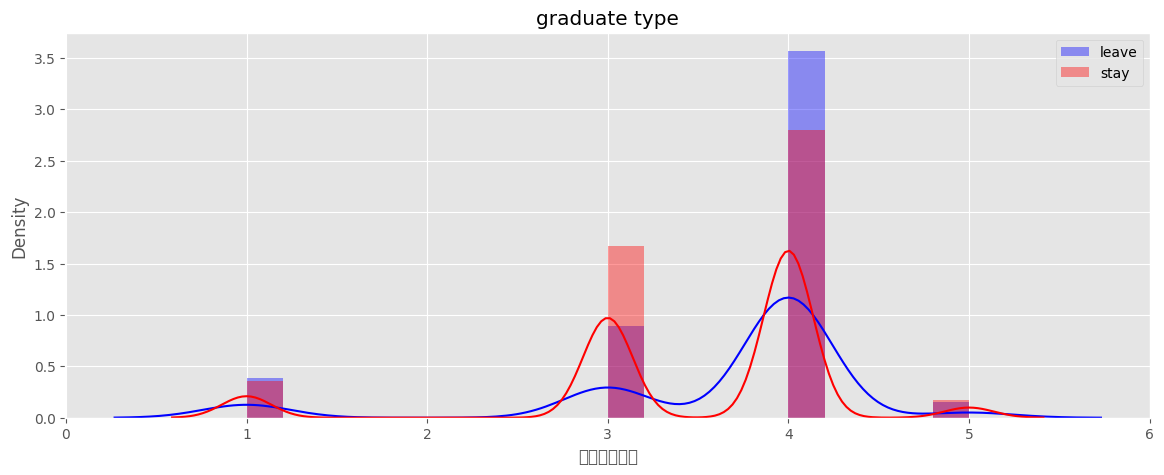

In [ ]:
index_S = df_data[(df_data.畢業學校類別.notna()) & (df_data.PerStatus==1)]
index_D = df_data[(df_data.畢業學校類別.notna()) & (df_data.PerStatus==0)]

plt.figure(figsize=(14,5))
# Check if index_S is not empty before plotting
if not index_S.empty:
    sns.distplot(index_S['畢業學校類別'], bins=20, color='blue', label='leave')
# Check if index_D is not empty before plotting
if not index_D.empty:
    sns.distplot(index_D['畢業學校類別'], bins=20, color='red', label='stay')
plt.title('graduate type')
plt.legend()
plt.show()

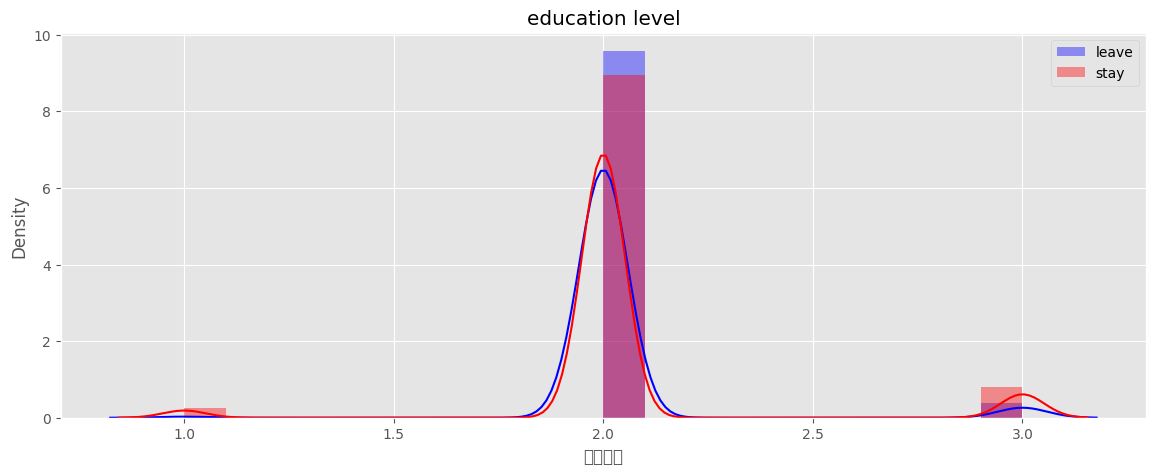

In [ ]:
from typing_extensions import NotRequired
index_S = df_data[(df_data.最高學歷.notna()) & (df_data.PerStatus==1)]
index_D = df_data[(df_data.最高學歷.notna()) & (df_data.PerStatus==0)]

plt.figure(figsize=(14,5))
# Check if index_S is not empty before plotting
if not index_S.empty:
    sns.distplot(index_S['最高學歷'], bins=20, color='blue', label='leave')
# Check if index_D is not empty before plotting
if not  index_D.empty:
    sns.distplot(index_D['最高學歷'], bins=20, color='red', label='stay')
plt.title('education level')
plt.legend()
plt.show()

根據圖表可以看出最高學歷間與離職率並無顯著的關係，故在遺漏值處理中最高學歷遺漏值以其眾數填補


In [ ]:
import pandas as pd

# Impute missing values with the mode
for col in ['最高學歷']:
    mode_value = df_data[col].mode()[0]  # Get the most frequent value
    df_data[col] = df_data[col].fillna(mode_value)

比較畢業學校類別遺漏值中的畢業科系類別

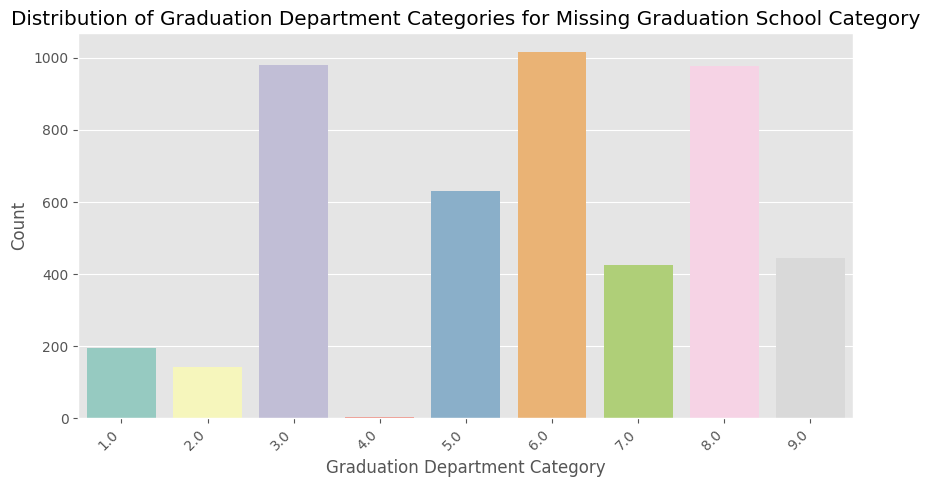

In [ ]:
# Filter data with missing '畢業學校類別'
missing_school_data = df_data[df_data['畢業學校類別'].isnull()]

# Convert '畢業科系類別' to numerical if necessary
if missing_school_data['畢業科系類別'].dtype == 'object':
    missing_school_data['畢業科系類別'] = missing_school_data['畢業科系類別'].astype('category').cat.codes

# Create a figure and axes
plt.figure(figsize=(10, 5))

# Create the countplot
ax = sns.countplot(x='畢業科系類別', data=missing_school_data, palette='Set3')

# Set labels and title
ax.set_title('Distribution of Graduation Department Categories for Missing Graduation School Category')
ax.set_xlabel('Graduation Department Category')
ax.set_ylabel('Count')

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Show the plot
plt.show()

畢業學校類別的遺漏項依照其所屬畢業科系類別的畢業學校類別最高次數者進行缺漏項填補

In [ ]:
# Group by '畢業科系類別' and get the mode of '畢業學校類別' for each group
mode_by_department = df_data.groupby('畢業科系類別')['畢業學校類別'].agg(lambda x: x.mode()[0] if not x.mode().empty else pd.NA)

# Function to impute missing values
def impute_missing_school(row):
    if pd.isnull(row['畢業學校類別']):
        return mode_by_department.get(row['畢業科系類別'], pd.NA)  # Get mode for the department, or pd.NA if not found
    else:
        return row['畢業學校類別']

# Apply the imputation function to the '畢業學校類別' column
df_data['畢業學校類別'] = df_data.apply(impute_missing_school, axis=1)

最後再確認一次遺漏值是否皆處理完畢

In [ ]:
Missing_Counts( df_data.drop('PerStatus', axis=1) )

,ColumnName,MissingCount,Percentage(%)


#離群值
因為使用樹狀模型來預測結果故不特別處理離群值

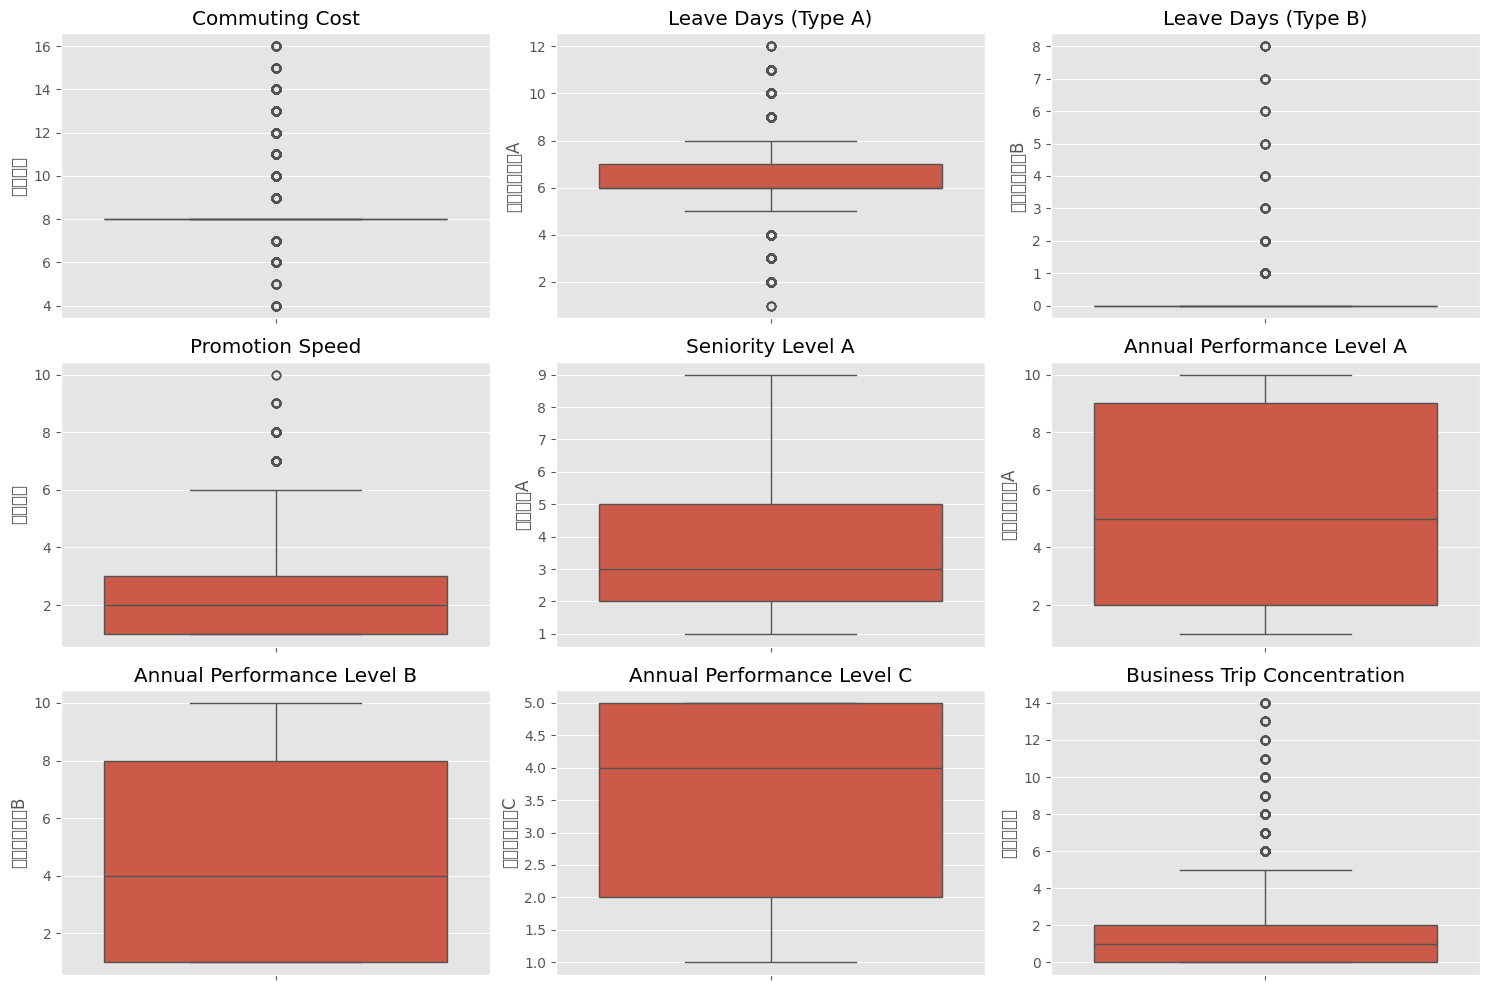

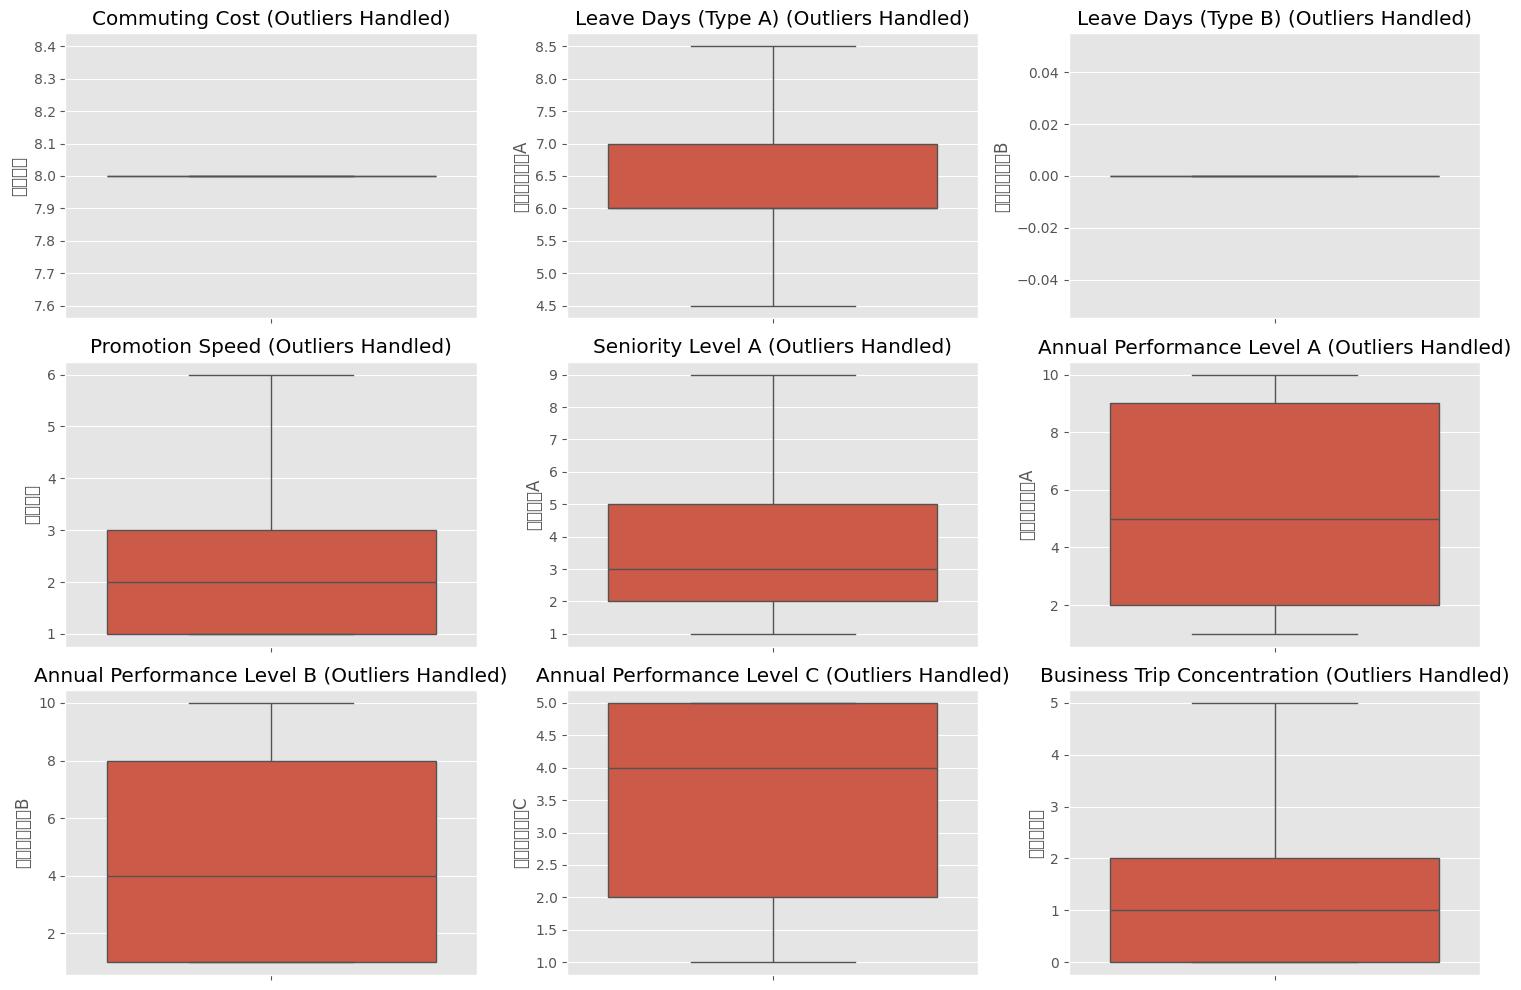

In [ ]:
outlier_vars = ['通勤成本', '近一年請假數A', '近一年請假數B', '升遷速度', '年資層級A',
                 '年度績效等級A', '年度績效等級B', '年度績效等級C', '出差集中度']  # 修改此處


english_titles = {
    '通勤成本': 'Commuting Cost',
    '近一年請假數A': 'Leave Days (Type A)',
    '近一年請假數B': 'Leave Days (Type B)',
    '升遷速度': 'Promotion Speed',
    '年資層級A': 'Seniority Level A',
    '年度績效等級A': 'Annual Performance Level A',
    '年度績效等級B': 'Annual Performance Level B',
    '年度績效等級C': 'Annual Performance Level C',
    '出差集中度': 'Business Trip Concentration'
}


plt.figure(figsize=(15, 10))
for i, var in enumerate(outlier_vars):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_data[var])
    plt.title(english_titles.get(var, var))  # Use English title if available, otherwise use original
plt.tight_layout()
plt.show()

# 使用 IQR 方法识别和处理离群值
def handle_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 将离群值替换为上下限
    data[column] = np.clip(data[column], lower_bound, upper_bound)
    return data

# 对每个变量应用 IQR 方法
for var in outlier_vars:
    df_data = handle_outliers_iqr(df_data, var)  # 使用修改後的變數名稱

# 再次使用箱线图可视化处理后的数据
plt.figure(figsize=(15, 10))
for i, var in enumerate(outlier_vars):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_data[var])  # 使用修改後的變數名稱
    plt.title(english_titles.get(var, var) + ' (Outliers Handled)')  # Use English title if available
plt.tight_layout()
plt.show()

# 訓練集(Train)與測試集(Test)

(2)
特徵挑選與個別分析


In [ ]:
# 產生訓練集和測試集
Train = df_data[pd.notnull(df_data['PerStatus'])]  # Using 'PerStatus' instead of 'Survived'
Test = df_data[pd.isnull(df_data['PerStatus'])]    # Using 'PerStatus' instead of 'Survived'

# 訓練集刪除 PerNo 欄位；
# 測試集刪除 PerNo 與 PerStatus 欄位
Train.drop(['PerNo'], axis=1, inplace=True)
Test.drop(['PerNo', 'PerStatus'], axis=1, inplace=True)

# 將訓練集中的標籤欄位 PerStatus 單獨拆出
Y_Train = Train['PerStatus']  # Using 'PerStatus' instead of 'Survived'
X_Train = Train.drop(['PerStatus'], axis=1)  # Using 'PerStatus' instead of 'Survived'

print(f'Shape of X_Train = {X_Train.shape}')
print(f'Shape of Y_Train = {Y_Train.shape}')
print(f'Shape of Test = {Test.shape}')

Shape of X_Train = (14319, 41)
Shape of Y_Train = (14319,)
Shape of Test = (3721, 41)


# 特徵重要性(Feature Importance)
用Lasso來評估特徵欄位對於標籤欄位(PerStatus)的重要性

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler


# Prepare the data
numerical_features = df_data.select_dtypes(include=np.number).columns.tolist()  # Get numerical features
numerical_features.remove('PerStatus')  # Remove target variable if present
X_numerical = df_data[numerical_features]
y = df_data['PerStatus']

# Before scaling and fitting, drop rows with NaN in 'PerStatus'
df_cleaned = df_data.dropna(subset=['PerStatus'])  # Create a cleaned DataFrame
X_numerical = df_cleaned[numerical_features]
y = df_cleaned['PerStatus']

# Scale the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)


# Use LassoCV to select features
lasso = LassoCV(cv=5, random_state=42)  # Use 5-fold cross-validation
lasso.fit(X_scaled, y)

# Get feature importance (absolute values of coefficients)
feature_importance = pd.Series(np.abs(lasso.coef_), index=numerical_features).sort_values(ascending=False)

# Display feature ranking
print("Feature Ranking (Lasso):")
print(feature_importance)

Feature Ranking (Lasso):
sex          0.013849
年度績效等級C      0.011496
近三月請假數B      0.011096
年齡層級         0.011039
近一年請假數A      0.007610
眷屬量          0.006684
專案時數         0.006228
年資層級B        0.006224
特殊專案佔比       0.005922
訓練時數C        0.005747
近三月請假數A      0.005730
婚姻狀況         0.005625
升遷速度         0.005573
yyyy         0.005554
出差數B         0.004978
工作資歷等級       0.004756
專案總數         0.004482
管理層級         0.004042
廠區代碼         0.003767
工作地點         0.003528
任職前工作平均年數    0.003434
年資層級C        0.003222
職等           0.002998
出差集中度        0.002839
工作分類         0.002548
訓練時數B        0.002464
榮譽數          0.002432
年度績效等級A      0.002285
是否升遷         0.001689
出差數A         0.001419
PerNo        0.001392
年度績效等級B      0.001326
最高學歷         0.001319
生產總額         0.001289
畢業科系類別       0.000997
畢業學校類別       0.000658
訓練時數A        0.000020
年資層級A        0.000000
近一年請假數B      0.000000
當前專案角色       0.000000
通勤成本         0.000000
歸屬部門         0.000000
dtype: float64


# 建立模型

In [ ]:

RFC = RandomForestClassifier( n_estimators = 1000,
                              min_samples_split = 20,
                              min_samples_leaf = 1,
                              oob_score = True,
                              random_state = 1,
                              n_jobs = -1 )

# 訓練模型


In [ ]:
RFC.fit( X_Train, Y_Train )
print( 'oob_score = {:.6f}'.format(RFC.oob_score_) )

oob_score = 0.944689


將所有的特徵欄位餵入模型進行訓練，訓練完成的模型準確率約 94.4689%

In [ ]:
RFC_2 = RandomForestClassifier( n_estimators = 1000,
                                min_samples_split = 20,
                                min_samples_leaf = 1,
                                oob_score = True,
                                random_state = 1,
                                n_jobs = -1 )

# 篩選部份特徵欄位餵入模型進行訓練
SelectedFeatures = ['sex', '工作分類', '職等', '專案時數', '專案總數', '特殊專案佔比', '訓練時數C', '近三月請假數B', '出差數A', '年齡層級' ]
RFC_2.fit( X_Train[SelectedFeatures], Y_Train )

print( f'Selected Features :\n   {SelectedFeatures}' )
print( 'oob_score = {:.6f}'.format(RFC_2.oob_score_) )

Selected Features :
   ['sex', '工作分類', '職等', '專案時數', '專案總數', '特殊專案佔比', '訓練時數C', '近三月請假數B', '出差數A', '年齡層級']
oob_score = 0.944479


用Lasso篩選的變數準確率為94.4479%

In [ ]:
RFC_3 = RandomForestClassifier( n_estimators = 1000,
                                min_samples_split = 20,
                                min_samples_leaf = 1,
                                oob_score = True,
                                random_state = 1,
                                n_jobs = -1 )

# 篩選部份特徵欄位餵入模型進行訓練
SelectedFeatures = ['特殊專案佔比','升遷速度','出差數A','出差集中度','年度績效等級B','年資層級A','年資層級B','訓練時數C','近三月請假數B']
RFC_3.fit( X_Train[SelectedFeatures], Y_Train )

print( f'Selected Features :\n   {SelectedFeatures}' )
print( 'oob_score = {:.6f}'.format(RFC_3.oob_score_) )

Selected Features :
   ['特殊專案佔比', '升遷速度', '出差數A', '出差集中度', '年度績效等級B', '年資層級A', '年資層級B', '訓練時數C', '近三月請假數B']
oob_score = 0.944619


用前面分析篩選特徵的準確率有稍微提升，為94.4619%但仍不及使用全特徵

# Confusion matrix

先用RFC_3來觀察其Confusion matrix和F1 score及ROC和其AIC

F1-score(RFC_3): 0.0025


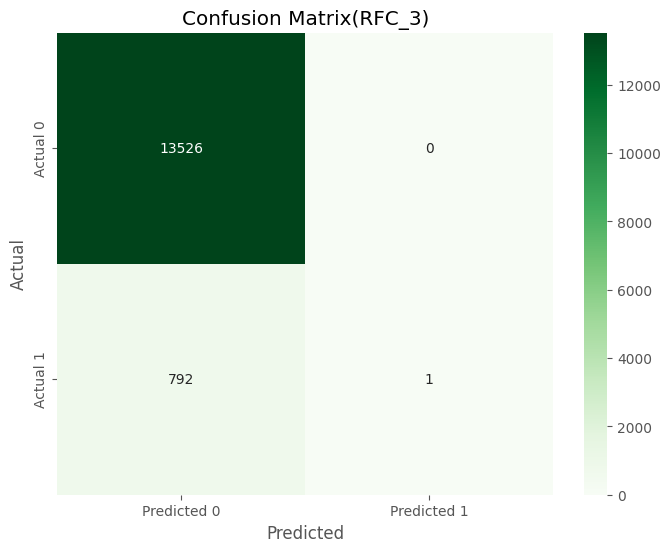

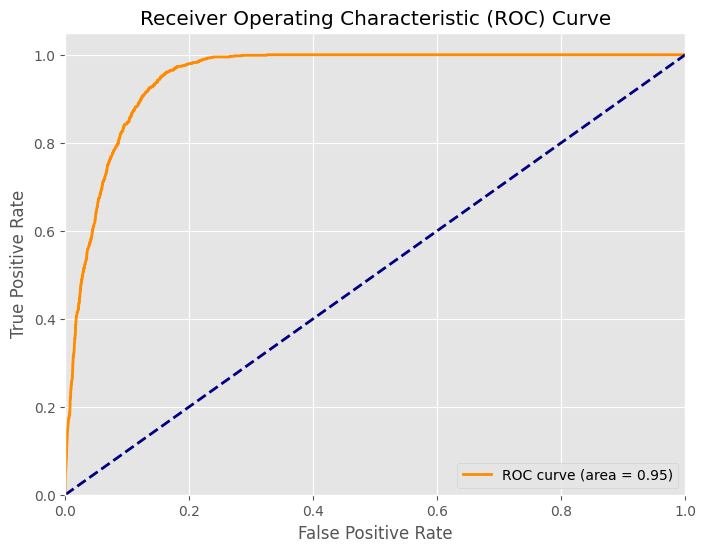

AUC: 0.9519


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score

# Predictions on the training data
X_pred = RFC_3.predict(X_Train[SelectedFeatures])

# Calculate F1-score
f1 = f1_score(Y_Train, X_pred)
print(f"F1-score(RFC_3): {f1:.4f}")

# Get predicted probabilities for ROC curve
# Use RFC_3 instead of RFC_2 for predict_proba
y_pred_prob = RFC_3.predict_proba(X_Train[SelectedFeatures])[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(Y_Train, y_pred_prob)

# Confusion Matrix (optional, you already have this in your code)
cm = confusion_matrix(Y_Train, X_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix(RFC_3)")
plt.show()

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
# Calculate AUC
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")


再用rf_model來觀察其Confusion matrix和F1 score及ROC和其AIC

F1-score (rf_model): 0.9992


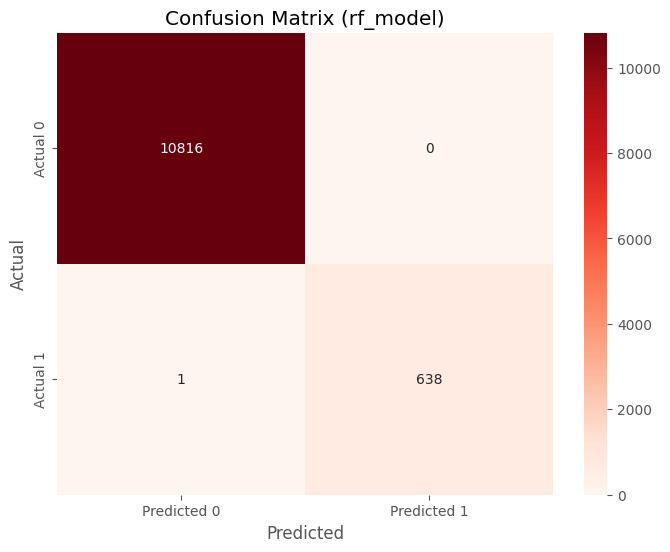

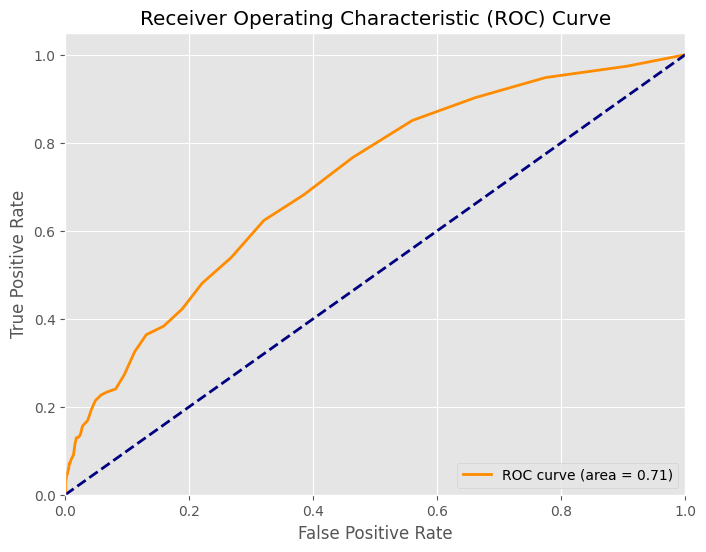

AUC: 0.7103


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_Train, Y_Train, test_size=0.2, random_state=42)

# Create and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the training set for confusion matrix and F1-score
y_pred_train = rf_model.predict(X_train)

# Calculate the confusion matrix for training data
cm_train = confusion_matrix(y_train, y_pred_train)

# Calculate the F1-score for training data
f1_train = f1_score(y_train, y_pred_train)

# Print the F1-score for training data
print(f"F1-score (rf_model): {f1_train:.4f}")

# Display the confusion matrix for training data
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (rf_model)")
plt.show()

# Make predictions on the test set for ROC and AUC
y_pred_test = rf_model.predict(X_test)
y_pred_proba_test = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Print AUC
print(f"AUC: {roc_auc:.4f}")

因專案目的為找出最高F1 score故最後選擇rf_model

# 測試集預測

In [ ]:

# Get the list of features used during training
training_features = X_train.columns.tolist()

# Ensure the Test DataFrame has the same features in the same order
Test = Test[training_features]

# make predictions on the test set using the trained rf_model and the correct features
Test_pred = rf_model.predict(Test)

# Get the indices from the original 'submit' DataFrame
original_indices = submit['PerNo']

# Create a new DataFrame with 'PerStatus' and a default index
submit_pred = pd.DataFrame({'PerStatus': Test_pred})

# Add a 'PerNo' column to submit_pred using the original indices
submit_pred['PerNo'] = original_indices.values[:len(submit_pred)]  # Use values to get a NumPy array

# merge based on 'PerNo'
submit = pd.merge(submit[['PerNo']], submit_pred, on='PerNo', how='left')

submit['PerStatus'] = submit['PerStatus'].fillna(df_data['PerStatus'].mode()[0])

# Save the predictions to a CSV file
submit.to_csv('Turnoverrate_Forest.csv', index=False)

print(f'預測結果：')
submit

預測結果：


,PerNo,PerStatus
0,1,0.0
1,3,0.0
2,7,0.0
3,15,0.0
4,16,0.0
...,...,...
3734,8761,0.0
3735,8765,0.0
3736,8767,0.0
3737,8774,0.0
